# Import Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import joblib

import sys
import os
sys.path.append(os.path.abspath('..'))

# Experiment data
exp2_data = pd.read_csv('../../../data/data_2/experiment_2.csv')

results_dir = '../../../data/model_fits/'

def load_results(folder, name_filter):
    results = {}
    prefixes = ("exp2_fit_", "exp2_xval_")
    
    for root, _, files in os.walk(folder):
        for fname in files:
            if name_filter in fname:
                path = os.path.join(root, fname)
                key = os.path.splitext(fname)[0]

                # Normalize keys so fit/cv share model names
                for prefix in prefixes:
                    if key.startswith(prefix):
                        key = key[len(prefix):]
                        break

                try:
                    with open(path, 'rb') as f:
                        results[key] = pickle.load(f)
                except Exception:
                    try:
                        results[key] = joblib.load(path)
                    except Exception:
                        pass
    return results

structure_name = 'BC_full'
fit_results = load_results(os.path.join(results_dir, 'fits'), structure_name)
cv_results = load_results(os.path.join(results_dir, 'cross_validation'), structure_name)

# Model Comparisons

In [2]:
# n_data = len(exp2_data)*3 # 3 responses per participant
n_data = (exp2_data[['A', 'C', 'D']].apply(abs).values.flatten()>0).sum() # only count non-zero responses

model_comparison = {}
for model,fit_data in fit_results.items():
    if model in cv_results:
        fit = fit_results[model]
        cv = cv_results[model]
        nll = fit['nll']
        k = fit['optimization_result'].x.shape[0]
        aic = 2*nll + 2*k
        bic = 2*nll + k*np.log(n_data)
        model_comparison[model] = {
            'fit_nll': nll,
            'cv_nll': np.mean(cv['test_nlls']),
            'n_params': fit['optimization_result'].x.shape[0],
            'aic': aic,
            'bic': bic
        }
model_comparison_df = (
    pd.DataFrame.from_dict(model_comparison, orient='index')
    .reset_index()
    .rename(columns={'index': 'model'})
)
model_comparison_df.sort_values('cv_nll', inplace=True)

In [3]:
# Best fitting aic models
model_comparison_df.sort_values(by='aic')

,model,fit_nll,cv_nll,n_params,aic,bic
5,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
2,BC_full_p1,509.072813,66.334009,9,1036.145625,1078.485355
3,BC_full_p0,572.851328,75.350588,9,1163.702656,1206.042385
1,BC_full_s1_p1,574.624154,72.010668,8,1165.248308,1202.883623
4,BC_full_s1,574.658756,72.178962,9,1167.317511,1209.657241
0,BC_full_s1_p0,612.634589,77.241732,8,1241.269178,1278.904493


In [4]:
# Best fitting bic models
model_comparison_df.sort_values(by='bic')

,model,fit_nll,cv_nll,n_params,aic,bic
5,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
2,BC_full_p1,509.072813,66.334009,9,1036.145625,1078.485355
1,BC_full_s1_p1,574.624154,72.010668,8,1165.248308,1202.883623
3,BC_full_p0,572.851328,75.350588,9,1163.702656,1206.042385
4,BC_full_s1,574.658756,72.178962,9,1167.317511,1209.657241
0,BC_full_s1_p0,612.634589,77.241732,8,1241.269178,1278.904493


In [5]:
# best fitting models cv_nll
model_comparison_df.sort_values(by='bic')

,model,fit_nll,cv_nll,n_params,aic,bic
5,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
2,BC_full_p1,509.072813,66.334009,9,1036.145625,1078.485355
1,BC_full_s1_p1,574.624154,72.010668,8,1165.248308,1202.883623
3,BC_full_p0,572.851328,75.350588,9,1163.702656,1206.042385
4,BC_full_s1,574.658756,72.178962,9,1167.317511,1209.657241
0,BC_full_s1_p0,612.634589,77.241732,8,1241.269178,1278.904493


## Comparing BC_full models

In [6]:
BC_full_df = model_comparison_df[(model_comparison_df['model'].str.contains('BC_full')) & #BC_full models
                     (~model_comparison_df['model'].str.contains('p1')) # Exclude p1 ablation for paper
                     ]

for index, row in BC_full_df.iterrows():
    print(f"{row['model']} & {row['fit_nll']:.1f} & {row['cv_nll']:.1f} & {row['aic']:.1f} & {row['bic']:.1f} & {row['n_params']} \\\\")

BC_full & 502.0 & 64.6 & 1024.1 & 1071.1 & 10 \\
BC_full_s1 & 574.7 & 72.2 & 1167.3 & 1209.7 & 9 \\
BC_full_p0 & 572.9 & 75.4 & 1163.7 & 1206.0 & 9 \\
BC_full_s1_p0 & 612.6 & 77.2 & 1241.3 & 1278.9 & 8 \\


In [7]:
BC_full_params = {m: f['fitted_params'] for m,f in fit_results.items() if 'BC_full' in m and not 'p1' in m}

In [8]:
# Print parameters for BC_full models in tabular format

# Create a list to store parameter data
param_data = []

for model_name, params in BC_full_params.items():
    param_row = {'Model': model_name}
    param_row.update(params)
    param_data.append(param_row)

# Create DataFrame
params_df = pd.DataFrame(param_data)

# Display as table
print("BC_full Model Parameters:")
print(params_df.round(2))

# Print as LaTeX table format
print("\nLaTeX format:")
print("\\begin{tabular}{" + "l" + "c" * (len(params_df.columns)-1) + "}")
print("\\hline")
header = " & ".join(params_df.columns) + " \\\\"
print(header)
print("\\hline")
for _, row in params_df.iterrows():
    latex_row = " & ".join([str(row[col]) if col == 'Model' else f"{row[col]:.2f}" for col in params_df.columns]) + " \\\\"
    print(latex_row)
print("\\hline")
print("\\end{tabular}")


BC_full Model Parameters:
           Model     s  temperature  p_keep    br  beta_A  beta_D  theta_AB  \
0  BC_full_s1_p0  1.00         1.33    0.00  0.25    0.67     0.0      0.75   
1     BC_full_p0  0.29         0.38    0.00  0.55    0.55     0.0      0.36   
2     BC_full_s1  1.00         0.98    0.97  0.09    0.36     0.0      0.70   
3        BC_full  1.00         0.32    0.66  0.24    0.47     0.0      0.59   

   theta_AC  theta_BD  theta_CD  
0      0.75      1.00      0.92  
1      0.00      0.86      0.94  
2      1.00      1.00      1.00  
3      0.73      0.78      0.98  

LaTeX format:
\begin{tabular}{lcccccccccc}
\hline
Model & s & temperature & p_keep & br & beta_A & beta_D & theta_AB & theta_AC & theta_BD & theta_CD \\
\hline
BC_full_s1_p0 & 1.00 & 1.33 & 0.00 & 0.25 & 0.67 & 0.00 & 0.75 & 0.75 & 1.00 & 0.92 \\
BC_full_p0 & 0.29 & 0.38 & 0.00 & 0.55 & 0.55 & 0.00 & 0.36 & 0.00 & 0.86 & 0.94 \\
BC_full_s1 & 1.00 & 0.98 & 0.97 & 0.09 & 0.36 & 0.00 & 0.70 & 1.00 & 1.00 & 

## Statistical checks

In [9]:
import scipy.stats as stats
BC_full_df

,model,fit_nll,cv_nll,n_params,aic,bic
5,BC_full,502.028785,64.623195,10,1024.057571,1071.101714
4,BC_full_s1,574.658756,72.178962,9,1167.317511,1209.657241
3,BC_full_p0,572.851328,75.350588,9,1163.702656,1206.042385
0,BC_full_s1_p0,612.634589,77.241732,8,1241.269178,1278.904493


In [10]:
# Compare Pearl models (s1 models)
pearl_models = BC_full_df[BC_full_df['model'].str.contains('s1')]
pearl_models = pearl_models.sort_values(by='cv_nll')


BC_full_s1_nll = pearl_models[pearl_models['model'] == 'BC_full_s1']['fit_nll'].iloc[0]
BC_full_s1_p0_nll = pearl_models[pearl_models['model'] == 'BC_full_s1_p0']['fit_nll'].iloc[0]
dof = 1 # degrees of freedom

chi2_stat = 2 * (BC_full_s1_p0_nll - BC_full_s1_nll)
p_value = 1 - stats.chi2.cdf(chi2_stat, dof)
print(f"Chi-squared statistic: {chi2_stat:.2f}, p-value: {p_value:.4f}")



Chi-squared statistic: 75.95, p-value: 0.0000


In [11]:
# Compare backtracking models (non-s1 models)
backtracking_models = BC_full_df[~BC_full_df['model'].str.contains('s1')].sort_values(by='cv_nll')

BC_full_nll = backtracking_models[backtracking_models['model'] == 'BC_full']['fit_nll'].iloc[0]
BC_full_p0_nll = backtracking_models[backtracking_models['model'] == 'BC_full_p0']['fit_nll'].iloc[0]
dof = 1  # degrees of freedom

chi2_stat_backtracking = 2 * (BC_full_p0_nll - BC_full_nll)
p_value_backtracking = 1 - stats.chi2.cdf(chi2_stat_backtracking, dof)

print(f"Chi-squared statistic: {chi2_stat_backtracking:.2f}, p-value: {p_value_backtracking:.4f}")

Chi-squared statistic: 141.65, p-value: 0.0000


# Figures

In [12]:
from CfModels.plotting import compare_order
from CfModels.fitting import make_priors

def get_order_preds(fit):
    params = fit['fitted_params']
    priors = make_priors(params)

    preds = {}
    for disj in [True, False]:
        for ques in [True, False]:
            print(f"Disjunction: {disj}, Question: {ques}")
            order_means = compare_order(beta_A=priors['beta_A'],
                        beta_B=priors['beta_B'],
                        beta_C=priors['beta_C'],
                        beta_D=priors['beta_D'],
                        power_B=priors['theta_AB'],
                        power_C=priors['theta_AC'], 
                            power_D_from_B=priors['theta_BD'],
                            power_D_from_C=priors['theta_CD'],
                        disjunction=disj,
                        question=ques,
                        s=params['s'],
                        p_keep=params['p_keep'],
                        temperature=params['temperature']
                        )
            disj_name = 'Disj' if disj else 'Conj'
            ques_name = 'B1' if ques else 'B0'
            preds[(disj_name, ques_name)] = {
                    'ACD': {'A' : order_means[0]['mean_A'], 'C': order_means[0]['mean_C'], 'D': order_means[0]['mean_D']},
                    'DCA': {'D' : order_means[1]['mean_D'], 'C': order_means[1]['mean_C'], 'A': order_means[1]['mean_A']},
                    }
    return preds


In [13]:
order_preds = get_order_preds(fit_results['BC_full'])

Disjunction: True, Question: True
Disjunction: True, Question: False
Disjunction: False, Question: True
Disjunction: False, Question: False


In [14]:
exp2_data.groupby(['structure', 'question','order'])[['A', 'C', 'D']].mean().apply(lambda x: (x + 1) / 2)

A       C       D
structure question order                        
1         0        1      0.5625  0.7375  0.5000
                   2      0.6875  0.8250  0.7500
          1        1      0.4750  0.3500  0.8125
                   2      0.4750  0.3875  0.8875
2         0        1      0.3750  0.5375  0.0875
                   2      0.6125  0.6875  0.0125
          1        1      0.5250  0.5375  0.5000
                   2      0.5375  0.2500  0.2125

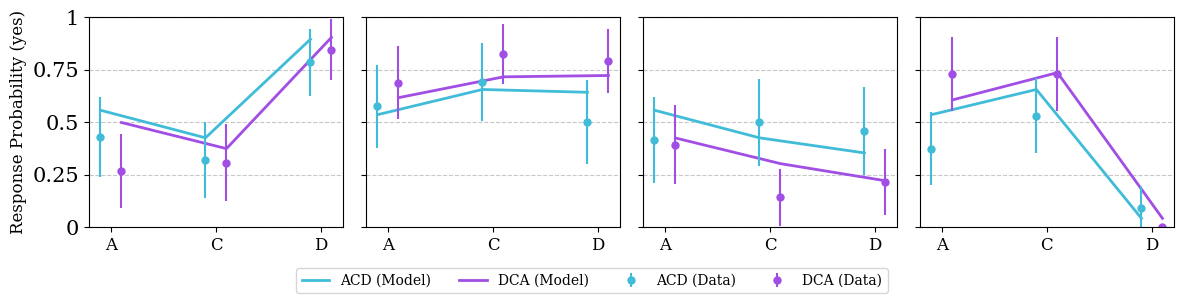

In [15]:
## Model Predictions - Order Effects Grid Plot

def plot_order_predictions_grid(order_pred_dict, exp_data, figsize=(12, 4), non_zero=True, save_fig=False):
    """
    Plot order predictions for all conditions in a 1x4 grid format.
    
    Parameters:
    order_pred_dict: dict with keys like ('Disj', 'B1') containing order predictions
    exp_data: DataFrame containing experimental data
    non_zero: bool, whether to filter out zero responses
    save_fig: bool, whether to save the figure
    """
    
    if non_zero:
        exp_data = exp_data[(exp_data['A'] != 0) & (exp_data['C'] != 0) & (exp_data['D'] != 0)]
    

    # Set text to computer modern
    plt.rcParams.update({"font.family": "serif",
                         "mathtext.fontset": "cm",
                         "font.size": 12})

    # Create figure with 1x4 subplots
    fig, axes = plt.subplots(1, 4, figsize=figsize)  # Increased height slightly for legend
    
    # Define conditions
    conditions = [('Disj', 'B1'), ('Disj', 'B0'), ('Conj', 'B1'), ('Conj', 'B0')]
    condition_titles = ['If $B$ had operated (Disjunctive)', 'If B had not operated (Disjunctive)', 'If $B$ had operated (Conjunctive)', 'If B had not operated (Conjunctive)']
    

    # Colors
    acd_color = '#40BCD8'
    dca_color = '#A14EE4'
    
    # Dodge for overlapping points
    dodge = 0.1
    
    for idx, ((disj_name, ques_name), title) in enumerate(zip(conditions, condition_titles)):
        ax = axes[idx]
        
        # Get model predictions
        if (disj_name, ques_name) in order_pred_dict:
            preds = order_pred_dict[(disj_name, ques_name)]
            
            # Convert condition names to booleans
            disj_bool = disj_name == 'Disj'
            ques_bool = ques_name == 'B1'
            
            # Filter experimental data
            structure_val = 1 if disj_bool else 2
            question_val = 1 if ques_bool else 0
            
            # Get data for each order
            acd_data_exp = exp_data[(exp_data['structure'] == structure_val) & 
                                   (exp_data['question'] == question_val) & 
                                   (exp_data['order'] == 1)]
            dca_data_exp = exp_data[(exp_data['structure'] == structure_val) & 
                                   (exp_data['question'] == question_val) & 
                                   (exp_data['order'] == 2)]
            
            # Calculate empirical means (convert -1,0,1 to 0,0.5,1 scale)
            def transform_response(x):
                return (x + 1) / 2
            
            acd_emp_means = [transform_response(acd_data_exp['A'].mean()),
                            transform_response(acd_data_exp['C'].mean()),
                            transform_response(acd_data_exp['D'].mean())]
            
            dca_emp_means = [transform_response(dca_data_exp['A'].mean()),
                            transform_response(dca_data_exp['C'].mean()),
                            transform_response(dca_data_exp['D'].mean())]
            
            adc_emp_sems = [acd_data_exp['A'].sem(),
                           acd_data_exp['C'].sem(),
                           acd_data_exp['D'].sem()]
            dca_emp_sems = [dca_data_exp['A'].sem(),
                           dca_data_exp['C'].sem(),
                           dca_data_exp['D'].sem()]
            
            # Extract model predictions
            acd_data = preds['ACD']
            dca_data = preds['DCA']
            
            # Create x positions for responses
            responses = ['A', 'C', 'D']
            x_pos = np.arange(len(responses))
            
            # Extract values for plotting
            acd_values = [acd_data[resp] for resp in responses]
            dca_values = [dca_data[resp] for resp in responses]
            
            # Model predictions (solid lines)
            ax.plot(x_pos-dodge, acd_values, color=acd_color, linestyle='-', label='ACD (Model)', linewidth=2)
            ax.plot(x_pos+dodge, dca_values, color=dca_color, linestyle='-', label='DCA (Model)', linewidth=2)
            
            # Empirical data (points with error bars)
            ax.errorbar([x - dodge for x in x_pos], acd_emp_means, yerr=adc_emp_sems, fmt='o', color=acd_color, label='ACD (Data)', markersize=5, linestyle='None', capsize=0)
            ax.errorbar([x + dodge for x in x_pos], dca_emp_means, yerr=dca_emp_sems, fmt='o', color=dca_color, label='DCA (Data)', markersize=5, linestyle='None', capsize=0)
        
        # Formatting
        ax.set_xticks(x_pos)
        ax.set_xticklabels(responses, fontsize=12)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        # ax.set_title(title, fontsize=8)
        
        # Only show y-axis labels and ticks on the first subplot
        if idx == 0:
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
            ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1'], fontsize=15)
            ax.set_ylabel('Response Probability (yes)',
                          fontsize=12)
        else:
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
            ax.set_yticklabels([])
    
    # Add legend below the subplots with 2 columns
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)
    
    plt.tight_layout()
    
    if save_fig:
        plt.savefig('figures/order_predictions_grid.pdf', bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

# Use the function with the existing order_preds data
plot_order_predictions_grid(order_preds, exp2_data, figsize=(12, 2.8), non_zero=True, save_fig=0)